# Workshop: APIs and prompt engineering

What an **API** is, how the **Google Gemini Python SDK** works (`Client`, `generate_content`, `contents`), and how **prompt engineering** shapes what you get back.

**Goals:**
- Use the **Gemini Python SDK** (`Client`, `generate_content`) to send prompts from Python  
- Explore how **`contents`** (strings and lists of strings) shapes what the model returns  
- Practice **prompt engineering** for tasks like generating `datascience` plotting code  

**Setup:** You need a **Google Gemini API key** from [Google AI Studio](https://aistudio.google.com/apikey). Do not share your key or commit it to git.


<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

# Part 1 - APIs and the Gemini SDK

An **Application Programming Interface (API)** lets programmers use services that other people have written. You often **don’t need to know how something is implemented**—only **what it does** and **how to call it**.

For example, with **NumPy**, when you call `np.average`, you trust that it returns the mean of the values you pass in—you don’t need the implementation details.

In this course you have used **RESTful** APIs (Genius, Wikipedia): you request a **URL** and get structured data back. **Gemini** can be used that way too; here we use Google’s **Python SDK** (`google-genai`): you build a **client** object and call methods like `generate_content`. That pattern is convenient when inputs and outputs are flexible text, and when you make many calls from Python.

**Resources**:

* [Gemini API Quickstart](https://ai.google.dev/gemini-api/docs/quickstart)
* [Google Gen AI Python SDK](https://googleapis.github.io/python-genai/)
* [Gemini API: Prompting Strategies](https://ai.google.dev/gemini-api/docs/prompting-strategies)
* [Ziem et al., Table 1](https://direct.mit.edu/view-large/figure/4722326/coli_a_00502_i004.tif): LLM prompting guidelines (useful for the final project)


## Install and import

Run the cell below to install `google-genai` and import the module.


In [14]:
%pip install google-genai -q
from google import genai

Note: you may need to restart the kernel to use updated packages.


## Gemini API key

Set your key below (or load from `os.environ["GOOGLE_API_KEY"]`). Obtain a key at [Google AI Studio](https://aistudio.google.com/apikey) if needed.

**Do not share your key** or commit it to git.


In [ ]:
#replace the "PLEASE_PASTE_YOUR_KEY_HERE" with your own key, make sure it is in the string format (e.g. " ")
GOOGLE_API_KEY = "PLEASE_PASTE_YOUR_KEY_HERE"

## [Tutorial] Chat interface to API


Consider the chat prompt shown in the screenshot, as well as (the start of) the model’s response.

<img src="gemini_page.png" alt="A screenshot of a Google Gemini chat prompt. Prompt is 'Explain how AI works in a few words.'. Response from Gemini chat is long but gets at the idea." width="800">


An **AI chatbot** (like what is shown in the screenshot) is an application *on top of* a **large language model (LLM)**. The **LLM** is what takes in user prompts and returns text responses. The **chatbot** is what filters input, perhaps converting and loading files with additional prompts, and returns filtered LLM responses back, perhaps with some HTML or Markdown formatting.

Let’s break down what is happening in the above screenshot:

* The user **prompt**: "Explain how AI works in a few words."
* The model **response**: "AI works by using algorithms to analyze..."
* The specified **model**: Here, it is "Fast" (note the dropdown in the bottom right). The other option is "Thinking." We’ll discuss model choice more below when we call the API.


### [Tutorial] Create the client then make the request

The structure of making a request:

1. **API client** — `genai.Client(api_key=...)` is your gateway; its methods expose different API calls.
1. **API request** — `client.models.generate_content` takes named arguments:
    * `model`: which LLM (here **Gemini 2.5 Flash**, like the **Fast** option in the web app).
    * `contents`: the **prompt** string.
1. **Response** — `response` is a Gemini-specific object; for this course we mainly use **`response.text`**, the model’s answer as a string.


In [16]:
client = genai.Client(api_key=GOOGLE_API_KEY)

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="Explain how AI works in a few words",
)
print(response.text)

AI learns patterns from data to make intelligent decisions.


### [Tutorial] Run the same request again

You do **not** need to recreate the client. Call `generate_content` again with the same prompt—**LLMs are stochastic (i.e. LLMs involve probabilistic randomness)**, so the wording may change.


In [ ]:
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="Explain how AI works in a few words",
)
print(response.text)

### [Tutorial] Example - restaurant suggestions

We pass in a different **string** for `contents`. Run the cell below as-is, then try editing the prompt (different city, budget, cuisine, etc.).


In [ ]:
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="What is the best restaurant in Auburn, Alabama? Give one recommendation and a short reason in bulleted format.",
    #please feel free to play around with a new string of contents to see how the model responds.

)
restaurant_str = response.text
print(restaurant_str)

<hr style="border: 1px solid #fdb515;" />


## [Tutorial] Different Gemini models (optional)

- **`gemini-2.5-flash`** — fast; use this while iterating on prompts.
- **`gemini-2.5-pro`** — often richer answers; **slower and costlier**.

**Discuss:** If you try both on the same prompt, what differs in length, tone, or specificity?


**Tip:** Prefer **Gemini 2.5 Flash** while iterating on prompts. **Pro** is slower and costlier; switch only when your prompt is working.


In [ ]:
# Optional: same prompt with Pro (may take ~30–90 seconds)
response_pro = client.models.generate_content(
    model="gemini-2.5-pro",
    contents=...,  # reuse the same prompt as above
)
print(response_pro.text)

<hr style="border: 1px solid #fdb515;" />

# Part 2 - Prompt Engineering

### What is a list?

A list is a collection of items (like `[item1, item2, item3]`): one container that holds many values, where each value has a position.

In real life, a list in Pytho is similar to:
- a grocery list (many items in one place)
- a playlist (songs in order)
- a backpack (one bag holding many things)
- recipe steps (order matters).

We use a list in contents to split a prompt into clear parts, such as role, task, and output format, instead of writing one long block of text. This makes prompts easier to reuse, edit, and combine.

### Lists of strings for `contents`

A **string** is a sequence of text characters in Python, written in quotes—for example `"Explain how AI works"` or `'Write one sentence.'`. Strings are how you represent words, sentences, and other text in code.

The Gemini API accepts several types for `contents`. Here we pass a **list of strings**—several text snippets grouped together—so you can **reuse** persona and format snippets across prompts.

## [Tutorial] Providing more context for prompts
In `client.models.generate_content`, the `model` argument is a **string**, `contents` in the examples so far is a **string**, and **`response.text`** is a **string**. When you pass several context pieces later, `contents` can be a **list of strings**.

From [Wikipedia](https://en.wikipedia.org/wiki/Prompt_engineering): **Prompt engineering** is the process of structuring or crafting a **prompt** (natural language instruction) in order to produce better outputs from a generative AI model.

<details>
<summary><b>Expand for an example: pass the prompt as a multiline string (<code>"""…"""</code>) in <code>contents</code></b></summary>

This cell uses a **multiline string** (`"""..."""`) unlike the code cell below that uses **list** in contents.


```python
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="""Imagine you are a UC Berkeley student talking to a fellow classmate.
    
    What is the best restaurant in Berkeley? Only include cheap meals under $15,
    and only consider restaurants that are open past 9pm.

    Format your response as a bulleted list. Limit your response to 200 words.
    """
)
```

print(response.text)
</details>

In [17]:
# Run this cell to see the demo.
#feel free to edit the strings for context_character, context_format, and question below to see how they affect the output.
context_character = "Imagine you are an exceptinal tour guide who is a local expert talking to a fellow friend."
context_format = "Format your response as a bulleted list and make sure each sentence starts in a new line. Limit your response to 200 words."
question =   "What is the best restaurant in Auburn, Alabama? Only include cheap meals under $15, and only consider restaurants that are open past 9pm."
#please feel free to play around with a new string of question to see how the model responds.


# do not edit anything below this line 
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[
        context_character,
        question,
        context_format,
    ],
)
print(response.text)

KeyboardInterrupt: 

<hr style="border: 1px solid #fdb515;" />

## Prompt Engineering: Check your understanding

Please run the following two cells below to import the necessary libraries that allows the code to correctly output the horizontal bar chart and we have included `cal_data` and `admit_by_dept_rate` tables for reference: 

In [ ]:
# Run this cell to import all the necessary libraries.
from datascience import *
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline
plt.style.use("ggplot")
import warnings
warnings.filterwarnings('ignore')

In Workshop 2: Visualization, you created an `admit_by_dept_rate` table that compute `admit_f_by_dept_rate` and `admit_m_by_dept_rate` to the admission **percentages** (between 0 and 100) of female and males to each department, respectively using the dataset from the `'UCBerkeley1973_Admission.csv'`. Then you used `admit_by_dept_rate` to create a bar chart visualization below using `admit_by_dept_rate.barh("Major")`:

<img src="../curriculum02/images/admit_by_dept_rate.png" alt="Total Rate bar chart and Admit Rate by Department" width="100%"/>

In [12]:
#Run this cell to create the cal_data table. Do not edit this cell.
cal_data = Table.read_table('UCBerkeley1973_Admission.csv')
cal_data.show(5)

Year,Major,Gender,Admission
1973,C,F,Rejected
1973,B,M,Admitted
1973,Other,F,Admitted
1973,Other,M,Admitted
1973,Other,M,Rejected


In [13]:
#Run this cell to create the admit_by_dept_rate table. Do not edit this cell.
admit_by_dept = cal_data.where("Admission", "Admitted").pivot('Gender', 'Major')
count_by_dept = cal_data.pivot('Gender', 'Major')

admit_f_by_dept_rate = admit_by_dept.column("F")/count_by_dept.column("F") * 100
admit_m_by_dept_rate = admit_by_dept.column("M")/count_by_dept.column("M") * 100

admit_by_dept_rate = Table().with_columns(
                        "Major", admit_by_dept.column("Major"),
                        "F Admit Rate", admit_f_by_dept_rate,
                        "M Admit Rate", admit_m_by_dept_rate)
admit_by_dept_rate

Major,F Admit Rate,M Admit Rate
A,82.4074,72.4956
B,68,63.0357
C,33.8954,36.9231
D,34.9333,33.0935
E,23.9186,27.7487
F,7.33138,5.89812
Other,37.6911,40.9526


## [Tutorial] LLM writes plotting code (without contexts)

In [ ]:
tutorial_question = "Write Python code to make a horizontal bar chart of admit rates by major and gender based on the provided table cal_data."

In [52]:
 # Reload so cal_data is a datascience Table (pasted LLM code below may overwrite this name with other types of tables)
preview = str(cal_data.take(5))
output_format = ("Give a complete, runnable Python code only (no truncation with ...) that user can copu and paste into another notebook cell without depending on other cells.",
                 "Do not add ```python or ``` at the beginning or end of your code.",
                 "Do not make any assumptions about the data instead make sure you provide all code necessary to run the code without depending on the other cells")

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[
        tutorial_question,
        f"Sample rows (for context only):\n{preview}",
        output_format
    ]
)

print(response.text)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Required for generating sample data

# --- 1. Create Sample Data ---
# This section generates a DataFrame with sample admission data.
# It simulates various majors, genders, and admission outcomes
# with some deliberate variations in admit rates to make the chart illustrative.
# You can replace this with your actual data loading if you have a CSV or other source.

# Set a random seed for reproducibility of the sample data
np.random.seed(42)

# Define possible categories
majors = ['Math', 'Physics', 'English', 'Computer Science', 'History', 'Biology']
genders = ['M', 'F']
admissions = ['Admitted', 'Rejected']

# Generate a base number of applications
num_applications = 1000

# Create an empty list to store individual application records
sample_records = []

# Generate applications with varying admit rates for different major-gender combinations
for major in majors:
    for gender in genders:
 

> **Note:** It is totally okay if code pasted from an LLM raises an error.
>
> LLMs do not have full context about your notebook state, installed packages, variable names, or file paths unless you provide that context explicitly. Treat generated code as a draft: run it, inspect errors, and revise prompts or code iteratively.

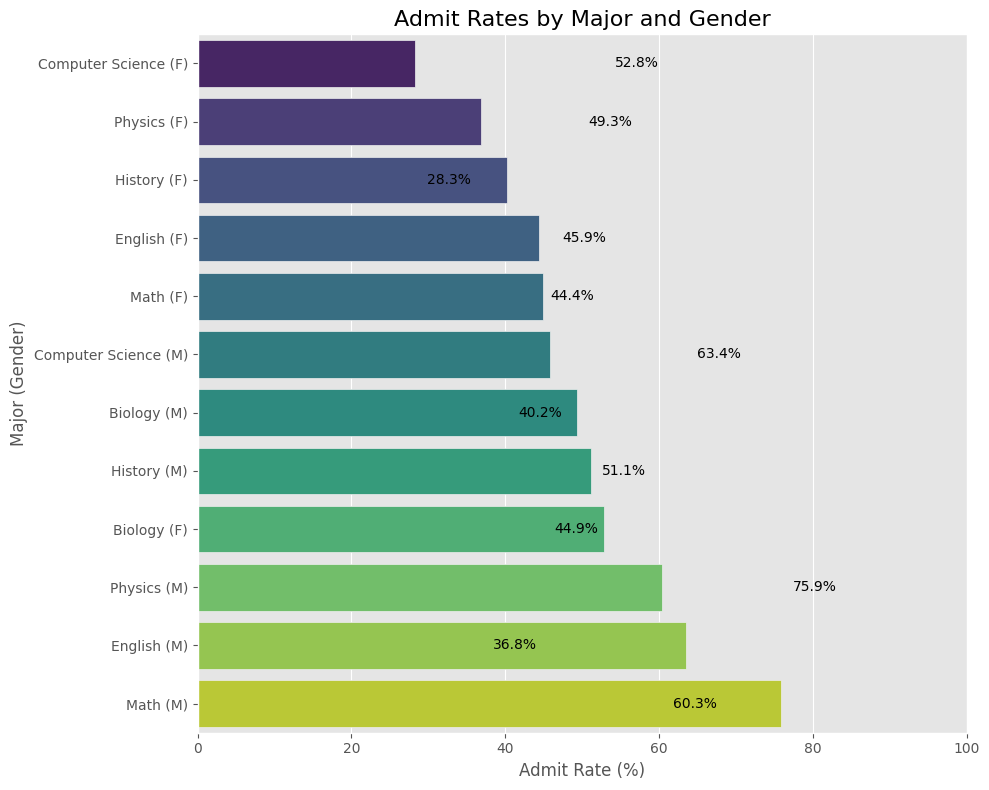

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Required for generating sample data

# --- 1. Create Sample Data ---
# This section generates a DataFrame with sample admission data.
# It simulates various majors, genders, and admission outcomes
# with some deliberate variations in admit rates to make the chart illustrative.
# You can replace this with your actual data loading if you have a CSV or other source.

# Set a random seed for reproducibility of the sample data
np.random.seed(42)

# Define possible categories
majors = ['Math', 'Physics', 'English', 'Computer Science', 'History', 'Biology']
genders = ['M', 'F']
admissions = ['Admitted', 'Rejected']

# Generate a base number of applications
num_applications = 1000

# Create an empty list to store individual application records
sample_records = []

# Generate applications with varying admit rates for different major-gender combinations
for major in majors:
    for gender in genders:
        # Determine a base admit rate for the current major-gender group
        base_admit_rate = 0.5 # Default 50%
        if major == 'Math' and gender == 'M':
            base_admit_rate = 0.75 # Higher admit rate
        elif major == 'Computer Science' and gender == 'F':
            base_admit_rate = 0.30 # Lower admit rate
        elif major == 'English' and gender == 'M':
            base_admit_rate = 0.60 # Slightly higher
        elif major == 'Physics' and gender == 'F':
            base_admit_rate = 0.40 # Slightly lower

        # Number of applications for this specific major-gender group
        # Distribute applications unevenly to make it more realistic
        group_size = int(num_applications * (np.random.rand() * 0.1 + 0.05)) # Between 5-15% of total
        if group_size == 0: group_size = 10 # Ensure at least some applications

        # Simulate admissions based on the calculated admit rate
        group_admissions = np.random.choice(
            admissions,
            size=group_size,
            p=[base_admit_rate, 1 - base_admit_rate]
        )

        for i in range(group_size):
            sample_records.append({
                'Year': np.random.choice([1973, 1974, 1975]),
                'Major': major,
                'Gender': gender,
                'Admission': group_admissions[i]
            })

df = pd.DataFrame(sample_records)

# --- 2. Process the Data to Calculate Admit Rates ---

# Count admissions for 'Admitted' and 'Rejected' for each Major and Gender group
admission_counts = df.groupby(['Major', 'Gender', 'Admission']).size().unstack(fill_value=0)

# Calculate total applications for each group
admission_counts['Total Applications'] = admission_counts['Admitted'] + admission_counts['Rejected']

# Calculate admit rate as a percentage
# Handle cases where 'Total Applications' might be 0 to avoid division by zero
# (though our sample data generation ensures at least 10 applications per group)
admission_counts['Admit Rate'] = (admission_counts['Admitted'] / admission_counts['Total Applications']) * 100
admission_counts['Admit Rate'] = admission_counts['Admit Rate'].fillna(0) # Fill NaN with 0 for groups with no applications

# Reset index to turn 'Major' and 'Gender' from index levels into columns
admit_rates_df = admission_counts.reset_index()

# Create a combined 'Major (Gender)' column for the y-axis labels
admit_rates_df['Major_Gender'] = admit_rates_df['Major'] + ' (' + admit_rates_df['Gender'] + ')'

# Sort the DataFrame by 'Admit Rate' for better readability in the chart
# Sorting ascending means the lowest rates will be at the bottom, highest at the top
admit_rates_df = admit_rates_df.sort_values(by='Admit Rate', ascending=True)

# --- 3. Create the Horizontal Bar Chart ---

plt.figure(figsize=(10, 8)) # Set the figure size for better readability

# Use seaborn.barplot to create the horizontal bar chart
sns.barplot(
    x='Admit Rate',
    y='Major_Gender',
    data=admit_rates_df,
    palette='viridis' # Choose a color palette for the bars
)

# Add chart title and axis labels
plt.title('Admit Rates by Major and Gender', fontsize=16)
plt.xlabel('Admit Rate (%)', fontsize=12)
plt.ylabel('Major (Gender)', fontsize=12)

# Set x-axis limit from 0 to 100 as it's a percentage
plt.xlim(0, 100)

# Add numerical labels to the bars for exact percentages
for index, row in admit_rates_df.iterrows():
    plt.text(
        row['Admit Rate'] + 1.5, # Position the text slightly to the right of the bar
        index,                  # Y-coordinate (index of the bar)
        f"{row['Admit Rate']:.1f}%", # Format the rate to one decimal place
        va='center',            # Vertical alignment
        ha='left',              # Horizontal alignment
        fontsize=10
    )

# Ensure all elements fit within the figure area
plt.tight_layout()

# Display the plot
plt.show()

## Hallucination

**Hallucination** is when the model generates plausible-looking output that is not faithful to the task requirements.

In this activity, hallucination can look like:
- using libraries other than `datascience`
- returning the wrong function name/signature
- using different column labels (not exactly `F Application Count` and `M Application Count`)
- making a stacked chart instead of an overlaid chart
- adding extra explanation text instead of only code

## Why Context Matters 
After adding explicit context in the prompt (dataset schema, allowed library, exact function name, exact relabel strings, chart type, and output format constraints), Gemini is much less likely to hallucinate because the solution space is tightly bounded.

So the key lesson is: we did not "make the model smarter"; we made the task specification precise enough that the model can follow it reliably.

<hr style="border: 1px solid #fdb515;" />


## Question: LLM writes plotting code (with contexts)

Now you will be asking Gemini to write a complete Python function called `num_applicant_bar(cal_data)` that reproduces the bar chart above from **Simpson’s paradox** style admissions data.

**Question:** Make sure your `question` variable includes the following:

- Clearly state the function name and its input parameter(s).
- Specify what the function should display or return regarding the number of applicants (e.g., an overlaid bar chart).
- Mention the dataset columns relevant for the plot (e.g., gender, major).
- Indicate the use of overlaid bars (not stacked) with a bar chart.

**Model:** Please use `gemini-2.5-flash`

**TASK:** **Please replace `...` with your **prompt string** and **model string**.**

**NOTE**: we have included necessary contexts into the list of `contents` already to ensure that the LLM model can produce the exact plot from Workshop 2.

<details>
<summary><b>HINT: Expand this cell to see an example sentence for the <code>question</code> variable that correctly generates the plot we want.</b></summary>

```python
question = "Generate a function called num_applicant_bar(cal_data) that takes a table and displays an overlaid bar chart of the number of applicants by gender and major"
```

</details>

In [ ]:
question = "..." #TODO: fill in the prompt
model = "..." #TODO: fill in the model name

In [25]:
question = "Generate a function called paradox_barh that takees cal_data as an input and displays a horizontal bar chart of the admit rates respectively to their gender and major" #TODO: fill in the prompt
model = "gemini-2.5-flash" #TODO: fill in the model name

In [39]:
#please do not edit anything in this cell
cal_data = Table.read_table('UCBerkeley1973_Admission.csv') #load the dataset again to ensure it is a datascience table
preview = str(cal_data.take(5))  #preview of the cal_data table 
context_dataset = "The table cal_data has columns Year, Major, Gender (F or M), Admission (Admitted or Rejected) and the data is loaded in for you"
context_imports = "You are only allowed to use `.pivot`, `.where`, and `.barh` from the datascience library in your code."
context_datascience_pivot = "datascience Table.pivot(columns, rows): the FIRST argument's unique values become column headers; the SECOND argument's unique values become the row labels (the leftmost column)."
context_datascience_where = "datascience Table.where(column, value): the FIRST argument is the column name and the SECOND argument is the value to filter the table by"
context_datascience_barh = "datascience Table.barh(column): the argument is the column name to display on the horizontal axis"
context_code_structure = "Do not include any other text than the function definition. Do not include texts like comments, etc."
context_function_steps = ("Calculatethe admission percentages(between 0 and 100) of female and males to each department using the dataset from cal_data."
                         "Make sure to store intermediate tables in variables"
                         "The values of Gender should be the columns of the pivot table and the values of Majors should be the rows of the pivot table")
context_barchart_components = "Make sure that the x-axis is Major and the legend is F Admit Rate and M Admit Rate"
context_function_output = "The function should take in a table and display a horizontal bar chart, and another line of code that passes in cal_data to the function"
context_reproducibility = ("Make sure the code is where the user can just copy and paste the code into a notebook cell and run it."
                          "Do not put any documentation or comments in the code."
                          "Do not include ```python or ``` at the beginning or end of your code.")

response = client.models.generate_content(
    model= model,
    contents=[
        f"Sample rows (for context only):\n{preview}",
        question,
        context_dataset,
        context_imports,
        context_datascience_pivot,
        context_datascience_where,
        context_datascience_barh,
        context_code_structure,
        context_function_steps,
        context_barchart_components,
        context_function_output,
        context_reproducibility
    ],
)
print(response.text)

from datascience import Table

def paradox_barh(cal_data):
    admitted_students = cal_data.where('Admission', 'Admitted')
    
    admitted_counts_pivot = admitted_students.pivot('Gender', 'Major')
    total_applicants_pivot = cal_data.pivot('Gender', 'Major')
    
    majors = total_applicants_pivot.column('Major')
    
    f_admitted = admitted_counts_pivot.column('F')
    m_admitted = admitted_counts_pivot.column('M')
    
    f_total = total_applicants_pivot.column('F')
    m_total = total_applicants_pivot.column('M')
    
    f_admit_rates = (f_admitted / f_total) * 100
    m_admit_rates = (m_admitted / m_total) * 100
    
    admit_rates_for_plot = Table().with_columns(
        'Major', majors,
        'F Admit Rate', f_admit_rates,
        'M Admit Rate', m_admit_rates
    )
    
    admit_rates_for_plot.barh('Major')

paradox_barh(cal_data)


**Test the model’s code:** paste the function into the cell below (or edit that cell until it runs), then run it.

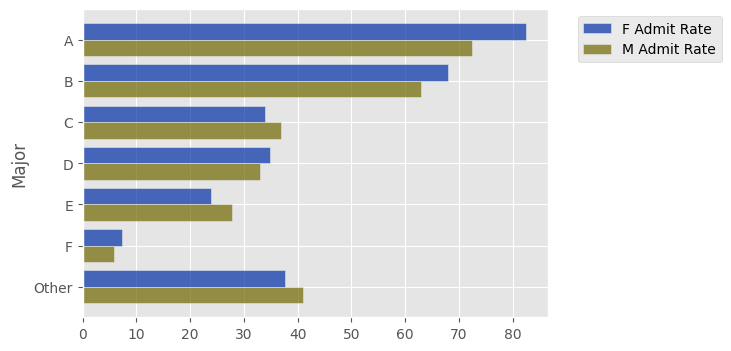

In [41]:
#TODO: copy and paste the code from the LLM here 
# and see if the model correctly made the function that generates the correct bart chart.

from datascience import Table

def paradox_barh(cal_data):
    admitted_students = cal_data.where('Admission', 'Admitted')
    
    admitted_counts_pivot = admitted_students.pivot('Gender', 'Major')
    total_applicants_pivot = cal_data.pivot('Gender', 'Major')
    
    majors = total_applicants_pivot.column('Major')
    
    f_admitted = admitted_counts_pivot.column('F')
    m_admitted = admitted_counts_pivot.column('M')
    
    f_total = total_applicants_pivot.column('F')
    m_total = total_applicants_pivot.column('M')
    
    f_admit_rates = (f_admitted / f_total) * 100
    m_admit_rates = (m_admitted / m_total) * 100
    
    admit_rates_for_plot = Table().with_columns(
        'Major', majors,
        'F Admit Rate', f_admit_rates,
        'M Admit Rate', m_admit_rates
    )
    
    admit_rates_for_plot.barh('Major')

paradox_barh(cal_data)

**Compare** the model's code with your code from Workshop 2 below:

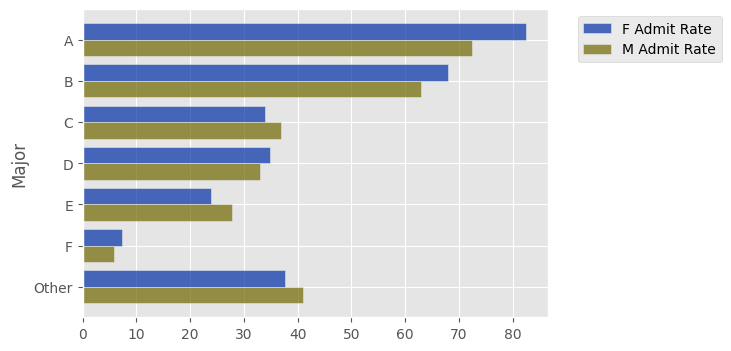

In [40]:
admit_by_dept_rate.barh("Major")

## Prompt engineering resources

* [Gemini API: Prompting Strategies](https://ai.google.dev/gemini-api/docs/prompting-strategies)
* [Ziem et al., Table 1](https://direct.mit.edu/view-large/figure/4722326/coli_a_00502_i004.tif)


<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />
